In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
lld1_file = "LLD1_VB-1E-8_slug4_20260512_161129.csv"
lld2_file = "LLD2_VB-1E-8_slug4_20260512_161129.csv"

lld1 = pd.read_csv(lld1_file)
lld2 = pd.read_csv(lld2_file)

In [3]:
# NEW - ignores any stale buffered rows from the csv
lld1 = lld1[lld1["arduino_ms"] < 1000000]
lld2 = lld2[lld2["arduino_ms"] < 1000000]

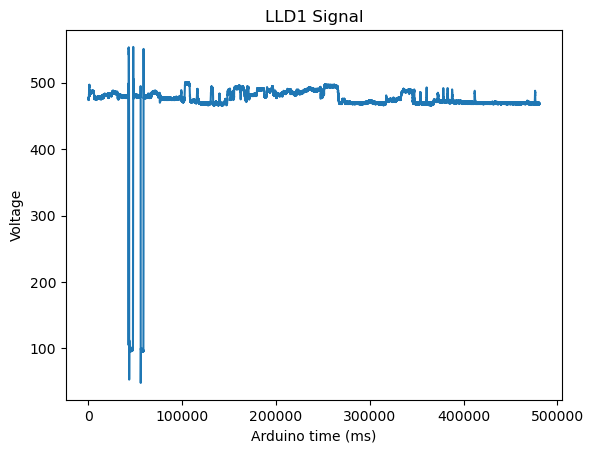

In [4]:
plt.figure()

plt.plot(lld1["arduino_ms"], lld1["analog_value"])

plt.title("LLD1 Signal")
plt.xlabel("Arduino time (ms)")
plt.ylabel("Voltage")

plt.show()

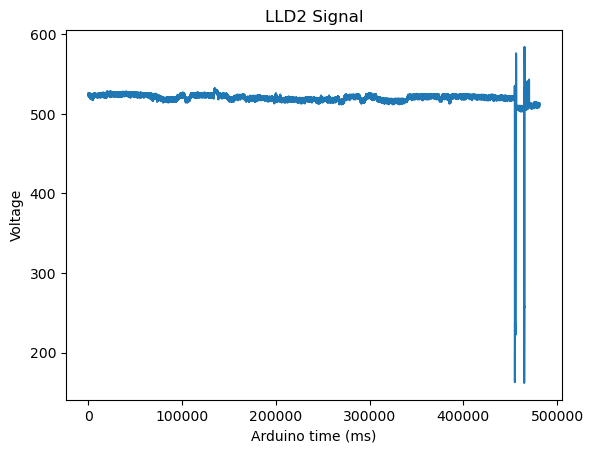

In [5]:
plt.figure()

plt.plot(lld2["arduino_ms"], lld2["analog_value"])

plt.title("LLD2 Signal")
plt.xlabel("Arduino time (ms)")
plt.ylabel("Voltage")

plt.show()

Note - the below are attempts at event capture

In [6]:
# Create time axes

lld1["time_s"] = (
    lld1["arduino_ms"] - lld1["arduino_ms"].iloc[0]
) / 1000

lld2["time_s"] = (
    lld2["arduino_ms"] - lld2["arduino_ms"].iloc[0]
) / 1000

In [7]:
threshold = 350

lld1_is_gas = lld1["analog_value"] < threshold
lld2_is_gas = lld2["analog_value"] < threshold

In [15]:
# Number of consecutive points required
# above threshold to confirm slug start
min_liquid_points = 100


def find_slug_start(df, threshold, min_liquid_points):

    is_gas = df["analog_value"] < threshold

    # first gas point
    first_gas_idx = is_gas.idxmax()

    values = df["analog_value"].values
    indices = df.index.values

    # start searching AFTER first gas
    start_pos = df.index.get_loc(first_gas_idx)

    for i in range(start_pos, len(df) - min_liquid_points):

        window = values[i:i + min_liquid_points]

        # all points in window above threshold
        if np.all(window > threshold):

            return indices[i]

    raise ValueError("No slug found")


lld1_slug_start_idx = find_slug_start(
    lld1,
    threshold,
    min_liquid_points
)

lld2_slug_start_idx = find_slug_start(
    lld2,
    threshold,
    min_liquid_points
)

lld1_slug_start_time = lld1.loc[
    lld1_slug_start_idx,
    "time_s"
]

lld2_slug_start_time = lld2.loc[
    lld2_slug_start_idx,
    "time_s"
]

In [16]:
lld1_gas = lld1[lld1["analog_value"] < threshold]
lld2_gas = lld2[lld2["analog_value"] < threshold]

lld1_first_gas = lld1_gas["time_s"].iloc[0]
lld1_last_gas = lld1_gas["time_s"].iloc[-1]

lld2_first_gas = lld2_gas["time_s"].iloc[0]
lld2_last_gas = lld2_gas["time_s"].iloc[-1]

lld1_start = lld1_first_gas - 2
lld1_end = lld1_last_gas + 2

lld2_start = lld2_first_gas - 2
lld2_end = lld2_last_gas + 2

In [17]:
lld1_trimmed = lld1[
    (lld1["time_s"] >= lld1_start) &
    (lld1["time_s"] <= lld1_end)
].copy()

lld2_trimmed = lld2[
    (lld2["time_s"] >= lld2_start) &
    (lld2["time_s"] <= lld2_end)
].copy()

In [18]:
lld1_trimmed["event_time_s"] = (
    lld1_trimmed["time_s"] - lld1_slug_start_time
)

lld2_trimmed["event_time_s"] = (
    lld2_trimmed["time_s"] - lld2_slug_start_time
)

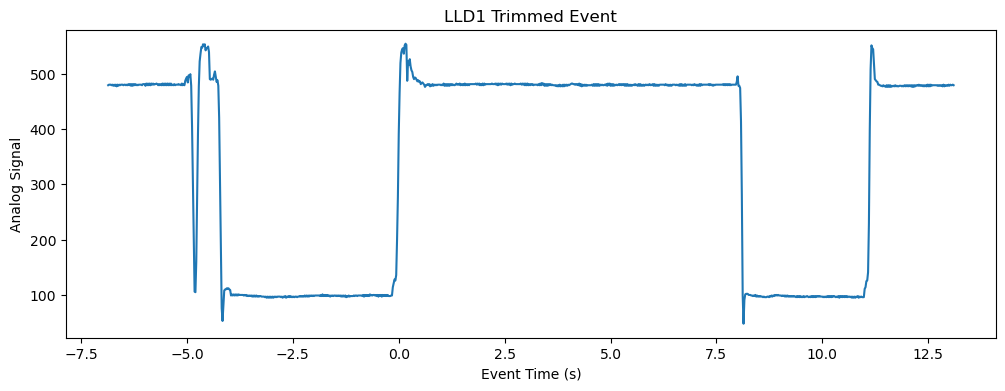

In [19]:
plt.figure(figsize=(12,4))

plt.plot(
    lld1_trimmed["event_time_s"],
    lld1_trimmed["analog_value"]
)

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("LLD1 Trimmed Event")

plt.show()

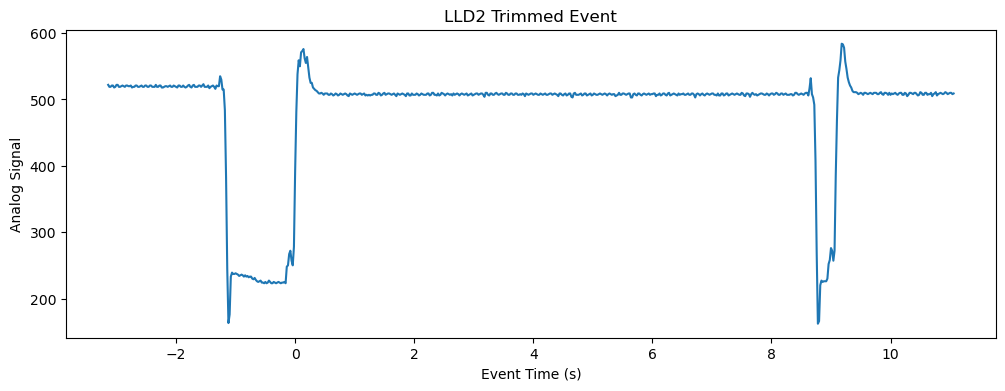

In [20]:
plt.figure(figsize=(12,4))

plt.plot(
    lld2_trimmed["event_time_s"],
    lld2_trimmed["analog_value"]
)

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("LLD2 Trimmed Event")

plt.show()

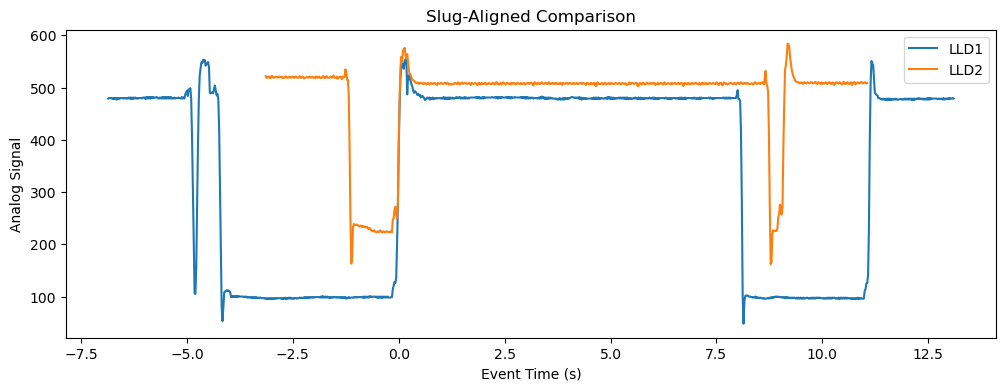

In [22]:
plt.figure(figsize=(12,4))

plt.plot(
    lld1_trimmed["event_time_s"],
    lld1_trimmed["analog_value"],
    label="LLD1"
)

plt.plot(
    lld2_trimmed["event_time_s"],
    lld2_trimmed["analog_value"],
    label="LLD2"
)

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("Slug-Aligned Comparison")

plt.legend()

plt.show()

The below is an initial attempt at extracting volume information from the region of the trimmed plots that correspond to a slug

In [28]:
threshold = 350

start_time = 0
end_time = float(input("Enter slug end time (s): "))

Enter slug end time (s):  9


In [29]:
def count_above_threshold(df, start_time, end_time, threshold):
    x = df["event_time_s"].values
    y = df["analog_value"].values

    mask = (x >= start_time) & (x <= end_time) & (y > threshold)

    return np.sum(mask), mask

In [30]:
lld1_count, lld1_mask = count_above_threshold(
    lld1_trimmed, start_time, end_time, threshold
)

lld2_count, lld2_mask = count_above_threshold(
    lld2_trimmed, start_time, end_time, threshold
)

print("LLD1 count:", lld1_count)
print("LLD2 count:", lld2_count)
print("Difference:", lld1_count - lld2_count)

LLD1 count: 405
LLD2 count: 438
Difference: -33


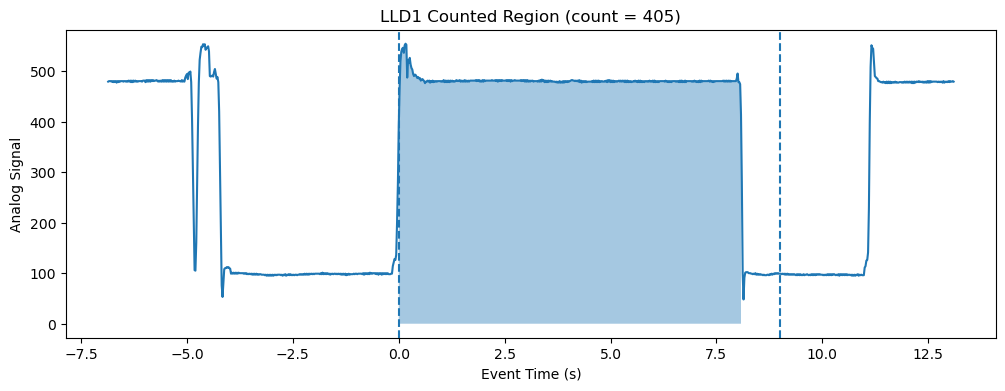

In [31]:
plt.figure(figsize=(12,4))

plt.plot(
    lld1_trimmed["event_time_s"],
    lld1_trimmed["analog_value"]
)

plt.fill_between(
    lld1_trimmed["event_time_s"],
    lld1_trimmed["analog_value"],
    where=lld1_mask,
    alpha=0.4
)

plt.axvline(
    start_time,
    linestyle="--"
)

plt.axvline(
    end_time,
    linestyle="--"
)

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")

plt.title(
    f"LLD1 Counted Region "
    f"(count = {lld1_count})"
)

plt.show()

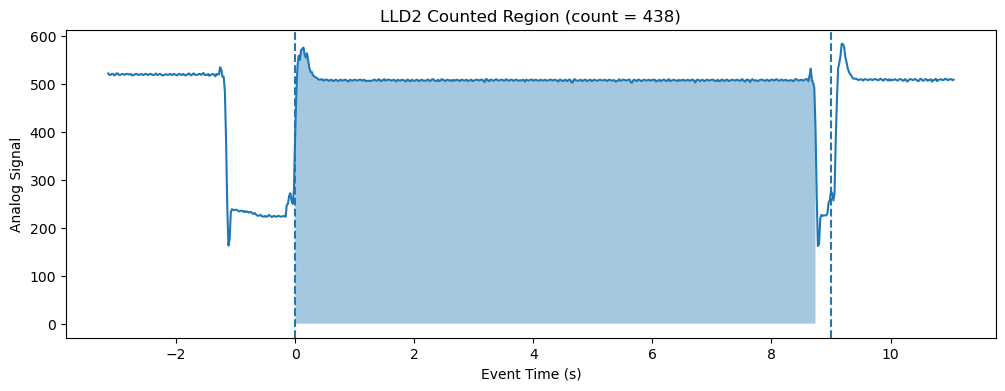

In [32]:
plt.figure(figsize=(12,4))

plt.plot(
    lld2_trimmed["event_time_s"],
    lld2_trimmed["analog_value"]
)

plt.fill_between(
    lld2_trimmed["event_time_s"],
    lld2_trimmed["analog_value"],
    where=lld2_mask,
    alpha=0.4
)

plt.axvline(
    start_time,
    linestyle="--"
)

plt.axvline(
    end_time,
    linestyle="--"
)

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")

plt.title(
    f"LLD2 Counted Region "
    f"(count = {lld2_count})"
)

plt.show()

In [15]:
def find_slug_end(df, threshold=350, min_persistence=10):
    x = df["event_time_s"].values
    y = df["analog_value"].values

    below = y < threshold

    count = 0

    for i in range(len(x)):
        if x[i] < 0:
            continue

        if below[i]:
            count += 1
        else:
            count = 0

        if count >= min_persistence:
            return x[i - min_persistence + 1]

    return x[-1]

In [16]:
threshold = 350
min_persistence = 10

end_time_s = find_slug_end(lld1_trimmed, threshold, min_persistence)

print("Detected slug end (s):", end_time_s)

Detected slug end (s): 0.5599999999999987


In [17]:
def slug_mask(df, end_time_s, threshold=350):
    x = df["event_time_s"].values
    y = df["analog_value"].values

    return (x >= 0) & (x <= end_time_s) & (y >= threshold)

In [18]:
lld1_mask = slug_mask(lld1_trimmed, end_time_s, threshold)
lld2_mask = slug_mask(lld2_trimmed, end_time_s, threshold)

lld1_count = np.sum(lld1_mask)
lld2_count = np.sum(lld2_mask)

print("LLD1 count:", lld1_count)
print("LLD2 count:", lld2_count)

print("Difference:", lld1_count - lld2_count)

LLD1 count: 28
LLD2 count: 27
Difference: 1


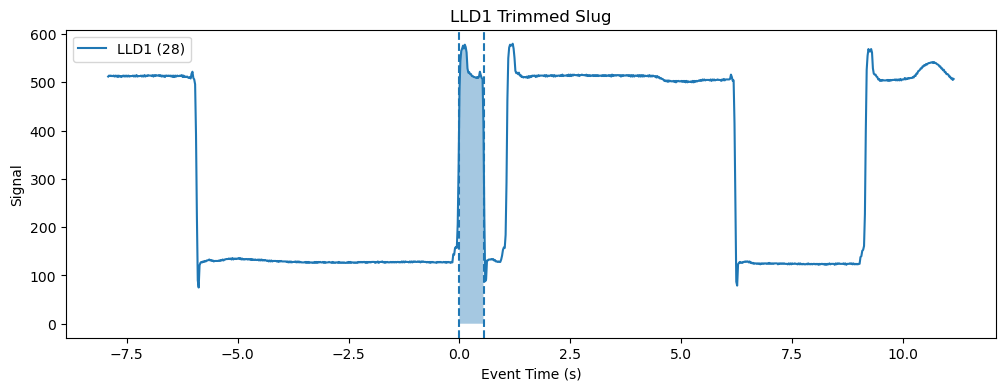

In [19]:
plt.figure(figsize=(12,4))

x = lld1_trimmed["event_time_s"]
y = lld1_trimmed["analog_value"]

plt.plot(x, y, label=f"LLD1 ({lld1_count})")

plt.fill_between(
    x,
    y,
    where=lld1_mask,
    alpha=0.4
)

plt.axvline(0, linestyle="--")
plt.axvline(end_time_s, linestyle="--")

plt.title("LLD1 Trimmed Slug")
plt.xlabel("Event Time (s)")
plt.ylabel("Signal")
plt.legend()

plt.show()

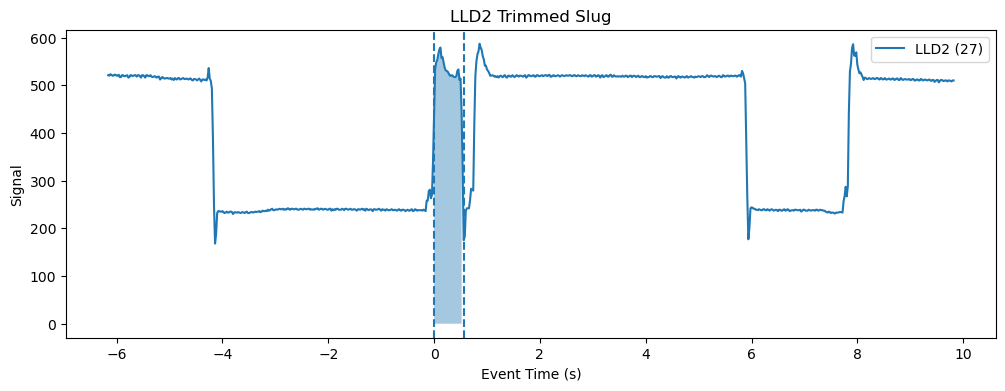

In [20]:
plt.figure(figsize=(12,4))

x = lld2_trimmed["event_time_s"]
y = lld2_trimmed["analog_value"]

plt.plot(x, y, label=f"LLD2 ({lld2_count})")

plt.fill_between(
    x,
    y,
    where=lld2_mask,
    alpha=0.4
)

plt.axvline(0, linestyle="--")
plt.axvline(end_time_s, linestyle="--")

plt.title("LLD2 Trimmed Slug")
plt.xlabel("Event Time (s)")
plt.ylabel("Signal")
plt.legend()

plt.show()

In [43]:
min_gas_persistence = 1  # adjust later (depends on sampling rate)

def extract_slug_regions(df, threshold=350, min_gas_persistence=5):
    signal = df["analog_value"].values
    n = len(signal)

    above = signal >= threshold

    # -----------------------------
    # STEP 1: find first gas event (validates segmentation has started)
    # -----------------------------
    first_gas_idx = np.where(signal < threshold)[0][0]

    # -----------------------------
    # STEP 2: find FIRST liquid AFTER that gas region (THIS is slug start)
    # -----------------------------
    slug_start = None

    in_gas = True

    for i in range(first_gas_idx, n):
        if signal[i] < threshold:
            in_gas = True
        else:
            if in_gas:
                slug_start = i
                break

    if slug_start is None:
        raise ValueError("No slug start found")

    # -----------------------------
    # STEP 3: find slug end with persistence filter
    # -----------------------------
    slug_end = n - 1

    i = slug_start
    while i < n:
        if signal[i] < threshold:
            # check persistence
            if i + min_gas_persistence < n:
                if np.all(signal[i:i+min_gas_persistence] < threshold):
                    slug_end = i
                    break
        i += 1

    # -----------------------------
    # STEP 4: mask + count
    # -----------------------------
    slug_mask = np.zeros(n, dtype=bool)
    slug_mask[slug_start:slug_end] = True

    slug_count = np.sum(signal[slug_start:slug_end] >= threshold)

    return slug_start, slug_end, slug_mask, slug_count

In [44]:
lld1_start, lld1_end, lld1_mask, lld1_count = extract_slug_regions(lld1_trimmed)
lld2_start, lld2_end, lld2_mask, lld2_count = extract_slug_regions(lld2_trimmed)

print("LLD1 slug count:", lld1_count)
print("LLD2 slug count:", lld2_count)

LLD1 slug count: 28
LLD2 slug count: 27


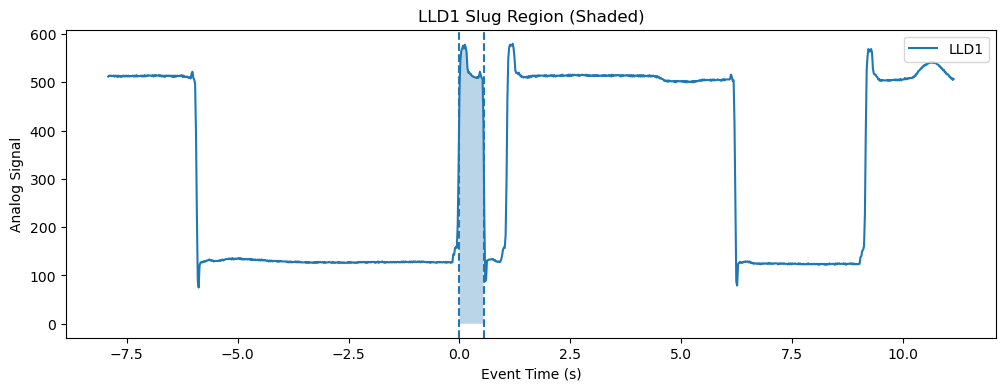

In [45]:
plt.figure(figsize=(12,4))

x = lld1_trimmed["event_time_s"]
y = lld1_trimmed["analog_value"]

plt.plot(x, y, label="LLD1")

plt.fill_between(
    x,
    y,
    where=lld1_mask,
    alpha=0.3
)

plt.axvline(x.iloc[lld1_start], linestyle="--")
plt.axvline(x.iloc[lld1_end], linestyle="--")

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("LLD1 Slug Region (Shaded)")
plt.legend()

plt.show()

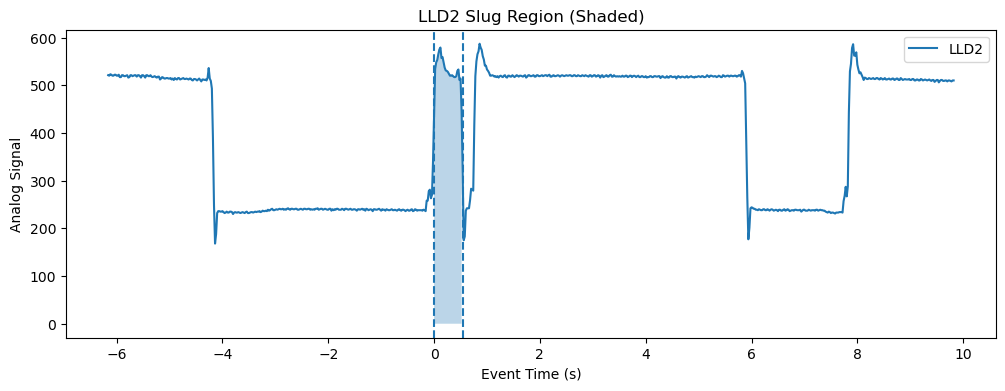

In [46]:
plt.figure(figsize=(12,4))

x = lld2_trimmed["event_time_s"]
y = lld2_trimmed["analog_value"]

plt.plot(x, y, label="LLD2")

plt.fill_between(
    x,
    y,
    where=lld2_mask,
    alpha=0.3
)

plt.axvline(x.iloc[lld2_start], linestyle="--")
plt.axvline(x.iloc[lld2_end], linestyle="--")

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("LLD2 Slug Region (Shaded)")
plt.legend()

plt.show()

Close, but this data has a breakup - want to shade that bit which is shaded above PLUS the bulk of the slug

In [51]:
import numpy as np

def extract_slug_regions(df, threshold=350,
                         micro_gap_max=5,
                         macro_gas_min=15,
                         min_slug_points=10):

    signal = df["analog_value"].values
    n = len(signal)
    is_liquid = signal >= threshold

    slug_start = None
    slug_end = None

    i = 0

    # -----------------------------
    # 1. find first gas (sync point)
    # -----------------------------
    while i < n and is_liquid[i]:
        i += 1

    # -----------------------------
    # 2. find slug start = stable liquid block
    # -----------------------------
    liquid_run = 0

    while i < n:
        if is_liquid[i]:
            liquid_run += 1
            if liquid_run >= min_slug_points:
                slug_start = i - min_slug_points + 1
                break
        else:
            liquid_run = 0
        i += 1

    if slug_start is None:
        raise ValueError("No slug start found")

    # -----------------------------
    # 3. scan forward with stability logic
    # -----------------------------
    gas_run = 0
    in_slug = True

    for j in range(slug_start, n):

        if is_liquid[j]:
            gas_run = 0

        else:
            gas_run += 1

            # ignore tiny gas blips inside slug
            if gas_run <= micro_gap_max:
                continue

            # only allow end AFTER slug has been stable
            if gas_run >= macro_gas_min:
                slug_end = j - gas_run + 1
                in_slug = False
                break

    if slug_end is None:
        slug_end = n - 1

    # -----------------------------
    # 4. mask + count
    # -----------------------------
    slug_mask = np.zeros(n, dtype=bool)
    slug_mask[slug_start:slug_end] = True

    slug_count = np.sum(signal[slug_start:slug_end] >= threshold)

    return slug_start, slug_end, slug_mask, slug_count

In [52]:
lld1_start, lld1_end, lld1_mask, lld1_count = extract_slug_regions(lld1_trimmed)
lld2_start, lld2_end, lld2_mask, lld2_count = extract_slug_regions(lld2_trimmed)

print("LLD1 slug count:", lld1_count)
print("LLD2 slug count:", lld2_count)

LLD1 slug count: 28
LLD2 slug count: 285


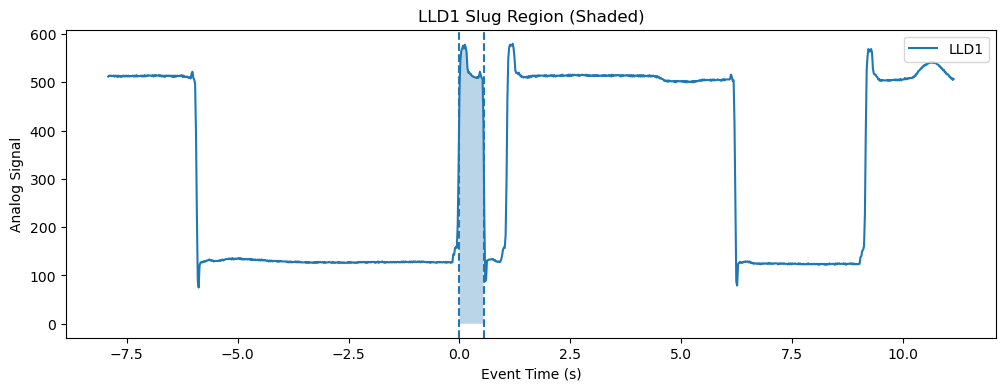

In [53]:
plt.figure(figsize=(12,4))

x = lld1_trimmed["event_time_s"]
y = lld1_trimmed["analog_value"]

plt.plot(x, y, label="LLD1")

plt.fill_between(
    x,
    y,
    where=lld1_mask,
    alpha=0.3
)

plt.axvline(x.iloc[lld1_start], linestyle="--")
plt.axvline(x.iloc[lld1_end], linestyle="--")

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("LLD1 Slug Region (Shaded)")
plt.legend()

plt.show()

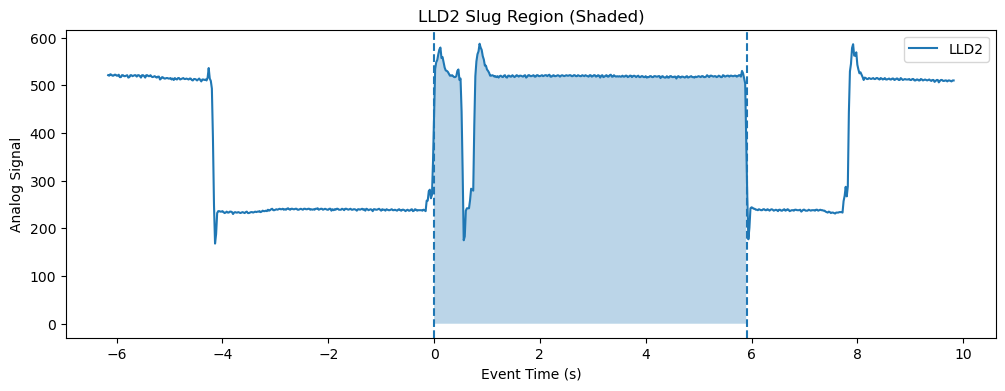

In [54]:
plt.figure(figsize=(12,4))

x = lld2_trimmed["event_time_s"]
y = lld2_trimmed["analog_value"]

plt.plot(x, y, label="LLD2")

plt.fill_between(
    x,
    y,
    where=lld2_mask,
    alpha=0.3
)

plt.axvline(x.iloc[lld2_start], linestyle="--")
plt.axvline(x.iloc[lld2_end], linestyle="--")

plt.xlabel("Event Time (s)")
plt.ylabel("Analog Signal")
plt.title("LLD2 Slug Region (Shaded)")
plt.legend()

plt.show()

Okay thats not working - im gonna try something else, maybe the user should just tell python where to count since this logic seems pretty flimsy

In [60]:
end_time_s = float(input("Enter slug end time (seconds from event start): "))

Enter slug end time (seconds from event start):  7


In [61]:
threshold = 350

def simple_slug_extract(df, end_time_s, threshold=350):

    x = df["event_time_s"]
    y = df["analog_value"]

    mask_time = (x >= 0) & (x <= end_time_s)
    mask_signal = y >= threshold

    slug_mask = mask_time & mask_signal

    slug_count = slug_mask.sum()

    return slug_mask, slug_count

In [62]:
lld1_mask, lld1_count = simple_slug_extract(lld1_trimmed, end_time_s)
lld2_mask, lld2_count = simple_slug_extract(lld2_trimmed, end_time_s)

print("LLD1 count:", lld1_count)
print("LLD2 count:", lld2_count)

LLD1 count: 285
LLD2 count: 285


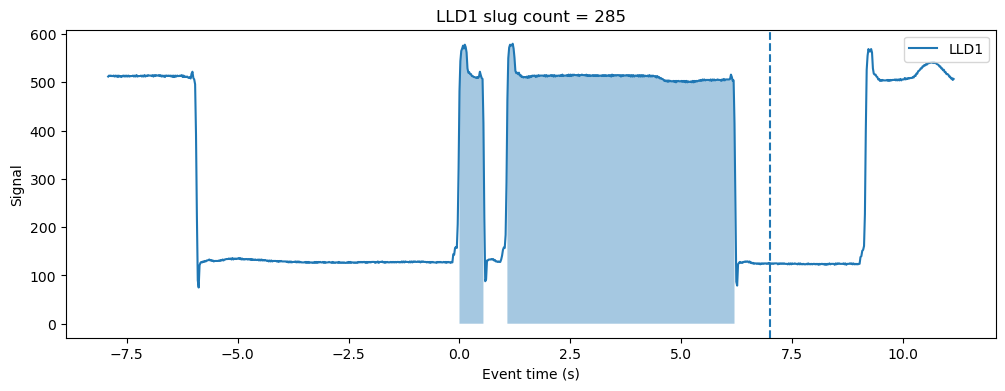

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

x = lld1_trimmed["event_time_s"]
y = lld1_trimmed["analog_value"]

plt.plot(x, y, label="LLD1")

plt.fill_between(
    x,
    y,
    where=lld1_mask,
    alpha=0.4
)

plt.axvline(end_time_s, linestyle="--")

plt.title(f"LLD1 slug count = {lld1_count}")
plt.xlabel("Event time (s)")
plt.ylabel("Signal")
plt.legend()
plt.show()

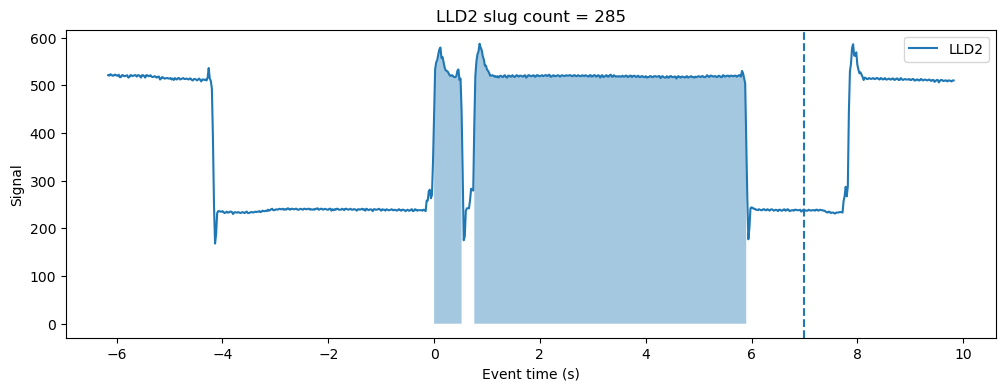

In [64]:
plt.figure(figsize=(12,4))

x = lld2_trimmed["event_time_s"]
y = lld2_trimmed["analog_value"]

plt.plot(x, y, label="LLD2")

plt.fill_between(
    x,
    y,
    where=lld2_mask,
    alpha=0.4
)

plt.axvline(end_time_s, linestyle="--")

plt.title(f"LLD2 slug count = {lld2_count}")
plt.xlabel("Event time (s)")
plt.ylabel("Signal")
plt.legend()
plt.show()

In [65]:
print(len(lld1_trimmed), len(lld2_trimmed))
print(lld1_trimmed["event_time_s"].head())
print(lld2_trimmed["event_time_s"].head())

954 800
686   -7.92
687   -7.90
688   -7.88
689   -7.86
690   -7.84
Name: event_time_s, dtype: float64
18203   -6.16
18204   -6.14
18205   -6.12
18206   -6.10
18207   -6.08
Name: event_time_s, dtype: float64


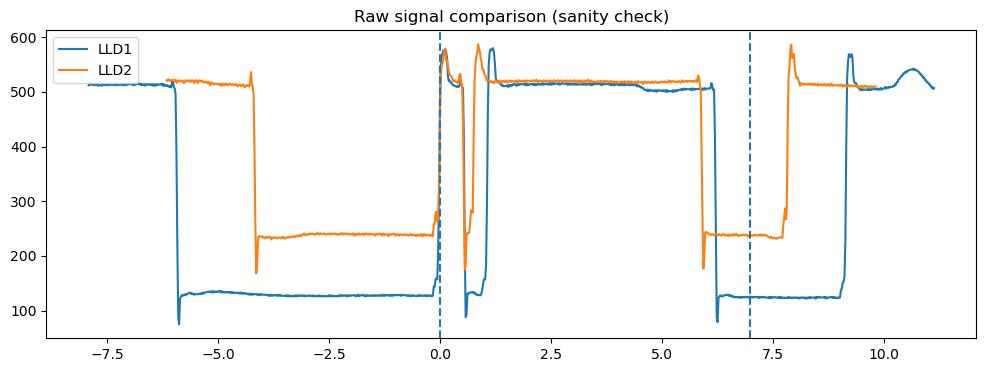

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(lld1_trimmed["event_time_s"], lld1_trimmed["analog_value"], label="LLD1")
plt.plot(lld2_trimmed["event_time_s"], lld2_trimmed["analog_value"], label="LLD2")

plt.axvline(0, linestyle="--")
plt.axvline(end_time_s, linestyle="--")

plt.legend()
plt.title("Raw signal comparison (sanity check)")
plt.show()

Okay the counts came off as exactly the same number - I dont believe that this is "true" fluidically - I think the post processing is over constrained

trying again....

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

lld1_file = "LLD1_VB-1E-8_slug_3_20260512_115207.csv"
lld2_file = "LLD2_VB-1E-8_slug_3_20260512_115207.csv"

lld1 = pd.read_csv(lld1_file)
lld2 = pd.read_csv(lld2_file)

In [2]:
threshold = 350

In [4]:
end_time_s = float(input("Enter slug end time (s): "))

Enter slug end time (s):  7


In [5]:
lld1["time_s"] = (lld1["arduino_ms"] - lld1["arduino_ms"].iloc[0]) / 1000
lld2["time_s"] = (lld2["arduino_ms"] - lld2["arduino_ms"].iloc[0]) / 1000

In [6]:
def slice_slug(df):
    return df[(df["time_s"] >= 0) & (df["time_s"] <= end_time_s)].copy()

lld1_s = slice_slug(lld1)
lld2_s = slice_slug(lld2)

In [7]:
lld1_metric = np.sum(np.maximum(lld1_s["analog_value"] - threshold, 0))
lld2_metric = np.sum(np.maximum(lld2_s["analog_value"] - threshold, 0))

In [8]:
print("LLD1 metric:", lld1_metric)
print("LLD2 metric:", lld2_metric)
print("Ratio (LLD2/LLD1):", lld2_metric / lld1_metric)

LLD1 metric: 54866
LLD2 metric: 60095
Ratio (LLD2/LLD1): 1.0953049247256954
